# 🧠 Google Analytics Customer Revenue Prediction
## Phase 3.5 — Feature Importance via Downsampled Cross-Validation

> **Competition:** [Google Analytics Customer Revenue Prediction](https://www.kaggle.com/c/ga-customer-revenue-prediction)  
> **Notebook Environment:** Kaggle Notebooks  
> **Input:** `users_train.csv` + `users_test.csv` from Phase 3  
> **Output:** `users_train_important.csv` + `users_test_important.csv` (your idea 🎯)

---

### 💡 The Idea (Your Strategy)

The dataset has a **severe class imbalance**: ~98% of users have zero revenue.
A normal feature importance run would be dominated by the majority class (non-buyers)
and fail to surface what actually drives a user to spend money.

**Solution — Downsampled Ensemble Cross-Validation:**

```
All non-buyers (98%)  →  shuffle  →  split into 10 equal chunks

For each chunk (10 iterations):
    Take ALL buyers (2%)
    +
    Take THIS chunk of non-buyers (~10% of 98%)
    ──────────────────────────────────────────
    Train LightGBM classifier: buyer vs non-buyer
    Record feature importance (gain)

Average importance scores across all 10 iterations
→ Features that consistently separate buyers are the real signal
```

This gives us **robust, bias-free feature importance** focused on what actually predicts revenue.

---

### 📌 Notebook Outputs

| File | Description |
|---|---|
| `feature_importance_scores.csv` | All features ranked by avg importance score |
| `feature_importance_scores.png` | Top 20 features visualization |
| `users_train_important.csv` | Train dataset with **only top features** |
| `users_test_important.csv` | Test dataset with **only top features** |

---

## 📦 Section 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import os
import gc
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid')

print('✅ Libraries imported')
print(f'📅 {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print(f'   LightGBM version: {lgb.__version__}')

✅ Libraries imported
📅 2026-03-19 03:41
   LightGBM version: 4.6.0


---
## 📂 Section 2 — Paths

> **Edit `PHASE3_PATH`** to point to your Phase 3 output dataset.

In [2]:
# ── Phase 3 output dataset ────────────────────────────────────────────────────
# Add Phase 3 output via: Add Data → Your Work → select Phase 3 notebook output
PHASE3_PATH = '/kaggle/input/datasets/mohnotif/phase-3/'

OUTPUT_PATH = '/kaggle/working/'

TRAIN_PATH = os.path.join(PHASE3_PATH, 'users_train.csv')
TEST_PATH  = os.path.join(PHASE3_PATH, 'users_test.csv')

# ── Config ────────────────────────────────────────────────────────────────────
NUM_CHUNKS   = 10    # number of non-buyer chunks (= number of LightGBM iterations)
TOP_N        = 25    # how many top features to keep in the output dataset
RANDOM_SEED  = 42

# ── Verify ────────────────────────────────────────────────────────────────────
for path, name in [(TRAIN_PATH, 'users_train.csv'), (TEST_PATH, 'users_test.csv')]:
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1e6:.1f} MB' if exists else 'NOT FOUND'
    print(f'  {"✅" if exists else "❌"}  {name:<25} {size}')

  ✅  users_train.csv           239.2 MB
  ✅  users_test.csv            51.9 MB


---
## 📥 Section 3 — Load Data

In [3]:
print('📂 Loading train dataset...')
train = pd.read_csv(TRAIN_PATH, dtype={'fullVisitorId': str}, low_memory=False)

print('📂 Loading test dataset...')
test  = pd.read_csv(TEST_PATH,  dtype={'fullVisitorId': str}, low_memory=False)

print(f'\n✅ Train shape : {train.shape}')
print(f'✅ Test shape  : {test.shape}')

# ── Sanity check: target column ───────────────────────────────────────────────
assert 'target' in train.columns, '❌ target column not found in train'
buyers = (train['target'] > 0).sum()
total  = len(train)
print(f'\n💰 Class balance:')
print(f'   Buyers     : {buyers:>8,}  ({buyers/total*100:.2f}%)')
print(f'   Non-buyers : {total-buyers:>8,}  ({(total-buyers)/total*100:.2f}%)')
print(f'   Imbalance ratio: 1 buyer per {(total-buyers)//buyers} non-buyers')

📂 Loading train dataset...
📂 Loading test dataset...

✅ Train shape : (1323730, 48)
✅ Test shape  : (296530, 46)

💰 Class balance:
   Buyers     :   16,141  (1.22%)
   Non-buyers : 1,307,589  (98.78%)
   Imbalance ratio: 1 buyer per 81 non-buyers


---
## ⚙️ Section 4 — Prepare Feature Matrix

In [4]:
# ── Drop non-feature columns ──────────────────────────────────────────────────
DROP_COLS = ['fullVisitorId', 'target', 'total_revenue']

X = train.drop(columns=[c for c in DROP_COLS if c in train.columns])
y = train['target']

# Binary target: 1 = buyer, 0 = non-buyer
y_binary = (y > 0).astype(int)

# ── Keep only numeric columns ─────────────────────────────────────────────────
X = X.select_dtypes(include=[np.number]).fillna(0)

print(f'✅ Feature matrix ready')
print(f'   Shape   : {X.shape}')
print(f'   Features: {X.shape[1]}')
print(f'   Buyers  : {y_binary.sum():,}')
print(f'   Non-buyers: {(y_binary == 0).sum():,}')

✅ Feature matrix ready
   Shape   : (1323730, 45)
   Features: 45
   Buyers  : 16,141
   Non-buyers: 1,307,589


---
## 🔁 Section 5 — Downsampled Cross-Validation

This is the core of your idea.

```
Iteration 1:  buyers + non_buyers_chunk_1  →  train LightGBM  →  record importance
Iteration 2:  buyers + non_buyers_chunk_2  →  train LightGBM  →  record importance
...                                                                      ...
Iteration 10: buyers + non_buyers_chunk_10 →  train LightGBM  →  record importance
                                                               ─────────────────────
                                                               Average all 10 scores
```

In [5]:
# ── Separate buyer and non-buyer indices ──────────────────────────────────────
buyers_idx     = y_binary[y_binary == 1].index.values
non_buyers_idx = y_binary[y_binary == 0].index.values

print(f'Buyers index size     : {len(buyers_idx):,}')
print(f'Non-buyers index size : {len(non_buyers_idx):,}')

# ── Shuffle non-buyers ────────────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)
shuffled_non_buyers = np.random.permutation(non_buyers_idx)

# ── Split into NUM_CHUNKS equal chunks ────────────────────────────────────────
non_buyer_chunks = np.array_split(shuffled_non_buyers, NUM_CHUNKS)

print(f'\nNon-buyer chunks: {NUM_CHUNKS}')
print(f'Each chunk size : ~{len(non_buyer_chunks[0]):,} users')
print(f'Ratio per iter  : {len(buyers_idx):,} buyers vs ~{len(non_buyer_chunks[0]):,} non-buyers')

Buyers index size     : 16,141
Non-buyers index size : 1,307,589

Non-buyer chunks: 10
Each chunk size : ~130,759 users
Ratio per iter  : 16,141 buyers vs ~130,759 non-buyers


In [6]:
# ── LightGBM config for feature scoring ───────────────────────────────────────
# We use gain importance: measures how much each feature actually
# improves the split quality (more meaningful than split count)
LGB_PARAMS = dict(
    n_estimators     = 200,
    learning_rate    = 0.05,
    num_leaves       = 31,
    max_depth        = 6,
    min_child_samples= 10,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = RANDOM_SEED,
    n_jobs           = -1,
    importance_type  = 'gain',  # gain = how much a feature improves a split
    verbose          = -1,
)

# ── Initialize score accumulator ──────────────────────────────────────────────
feature_scores       = pd.DataFrame({'Feature': X.columns})
feature_scores['Score_Sum']    = 0.0
feature_scores['Score_Sum_Split'] = 0.0  # also track split count as backup

auc_scores = []  # track AUC per iteration to monitor quality

print(f'🚀 Starting {NUM_CHUNKS}-fold downsampled evaluation...')
print(f'   Each iteration: {len(buyers_idx):,} buyers + ~{len(non_buyer_chunks[0]):,} non-buyers')
print()

for i, chunk_idx in enumerate(non_buyer_chunks, 1):

    # ── Build balanced subset ────────────────────────────────────────────────
    combined_idx = np.concatenate([buyers_idx, chunk_idx])
    X_subset     = X.loc[combined_idx]
    y_subset     = y_binary.loc[combined_idx]

    # ── Train ────────────────────────────────────────────────────────────────
    clf = lgb.LGBMClassifier(**LGB_PARAMS)
    clf.fit(X_subset, y_subset)

    # ── Record importance (gain) ──────────────────────────────────────────────
    feature_scores['Score_Sum'] += clf.feature_importances_

    # ── Also record split-count importance (for comparison) ───────────────────
    clf_split = lgb.LGBMClassifier(**{**LGB_PARAMS, 'importance_type': 'split'})
    clf_split.fit(X_subset, y_subset)
    feature_scores['Score_Sum_Split'] += clf_split.feature_importances_

    # ── AUC on this subset (as quality check) ─────────────────────────────────
    proba = clf.predict_proba(X_subset)[:, 1]
    auc   = roc_auc_score(y_subset, proba)
    auc_scores.append(auc)

    print(f'  ✔ Chunk {i:>2}/{NUM_CHUNKS}  |  '
          f'subset size: {len(combined_idx):>7,}  |  '
          f'train AUC: {auc:.4f}')

    del clf, clf_split, X_subset, y_subset
    gc.collect()

print(f'\n✅ All {NUM_CHUNKS} iterations complete')
print(f'   Mean AUC across iterations: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}')
print(f'   (High AUC = features are genuinely separating buyers from non-buyers)')

🚀 Starting 10-fold downsampled evaluation...
   Each iteration: 16,141 buyers + ~130,759 non-buyers

  ✔ Chunk  1/10  |  subset size: 146,900  |  train AUC: 1.0000
  ✔ Chunk  2/10  |  subset size: 146,900  |  train AUC: 1.0000
  ✔ Chunk  3/10  |  subset size: 146,900  |  train AUC: 1.0000
  ✔ Chunk  4/10  |  subset size: 146,900  |  train AUC: 1.0000
  ✔ Chunk  5/10  |  subset size: 146,900  |  train AUC: 1.0000
  ✔ Chunk  6/10  |  subset size: 146,900  |  train AUC: 1.0000
  ✔ Chunk  7/10  |  subset size: 146,900  |  train AUC: 1.0000
  ✔ Chunk  8/10  |  subset size: 146,900  |  train AUC: 1.0000
  ✔ Chunk  9/10  |  subset size: 146,900  |  train AUC: 1.0000
  ✔ Chunk 10/10  |  subset size: 146,899  |  train AUC: 1.0000

✅ All 10 iterations complete
   Mean AUC across iterations: 1.0000 ± 0.0000
   (High AUC = features are genuinely separating buyers from non-buyers)


---
## 📊 Section 6 — Compute & Rank Feature Scores

In [7]:
# ── Average across all iterations ────────────────────────────────────────────
feature_scores['Avg_Gain_Score']  = feature_scores['Score_Sum']       / NUM_CHUNKS
feature_scores['Avg_Split_Score'] = feature_scores['Score_Sum_Split'] / NUM_CHUNKS

# ── Normalize to 0-100 for readability ───────────────────────────────────────
max_gain  = feature_scores['Avg_Gain_Score'].max()
max_split = feature_scores['Avg_Split_Score'].max()
feature_scores['Normalized_Gain']  = (feature_scores['Avg_Gain_Score']  / max_gain  * 100).round(2)
feature_scores['Normalized_Split'] = (feature_scores['Avg_Split_Score'] / max_split * 100).round(2)

# ── Combined score: weighted average of gain and split ────────────────────────
# Gain is more meaningful; split count is a secondary signal
feature_scores['Combined_Score'] = (
    0.7 * feature_scores['Normalized_Gain'] +
    0.3 * feature_scores['Normalized_Split']
).round(2)

# ── Sort by combined score ────────────────────────────────────────────────────
feature_scores = (
    feature_scores
    .sort_values('Combined_Score', ascending=False)
    .drop(columns=['Score_Sum', 'Score_Sum_Split'])
    .reset_index(drop=True)
)
feature_scores.index += 1  # rank starts at 1

print('🏆 Top 25 Most Important Features for Predicting Revenue:')
print('='*75)
print(f'{"Rank":<6} {"Feature":<40} {"Gain":>8} {"Split":>8} {"Combined":>10}')
print('-'*75)
for rank, row in feature_scores.head(25).iterrows():
    print(f"{rank:<6} {row['Feature']:<40} {row['Normalized_Gain']:>7.1f}  {row['Normalized_Split']:>7.1f}  {row['Combined_Score']:>9.1f}")
print('='*75)

🏆 Top 25 Most Important Features for Predicting Revenue:
Rank   Feature                                      Gain    Split   Combined
---------------------------------------------------------------------------
1      log_total_revenue                          100.0     26.6       78.0
2      funnel_mean_action                           0.0    100.0       30.0
3      most_used_country                            0.1     64.5       19.4
4      funnel_max_action                           12.4     34.1       18.9
5      most_used_continent                          0.0     59.9       18.0
6      hits_sum                                     0.0     56.6       17.0
7      recency_days                                 0.0     47.0       14.1
8      checkout_rate                                0.3     37.7       11.5
9      time_on_site_sum                             0.0     38.2       11.4
10     pageviews_sum                                0.0     37.5       11.2
11     pageviews_max          

---
## 📈 Section 7 — Visualizations

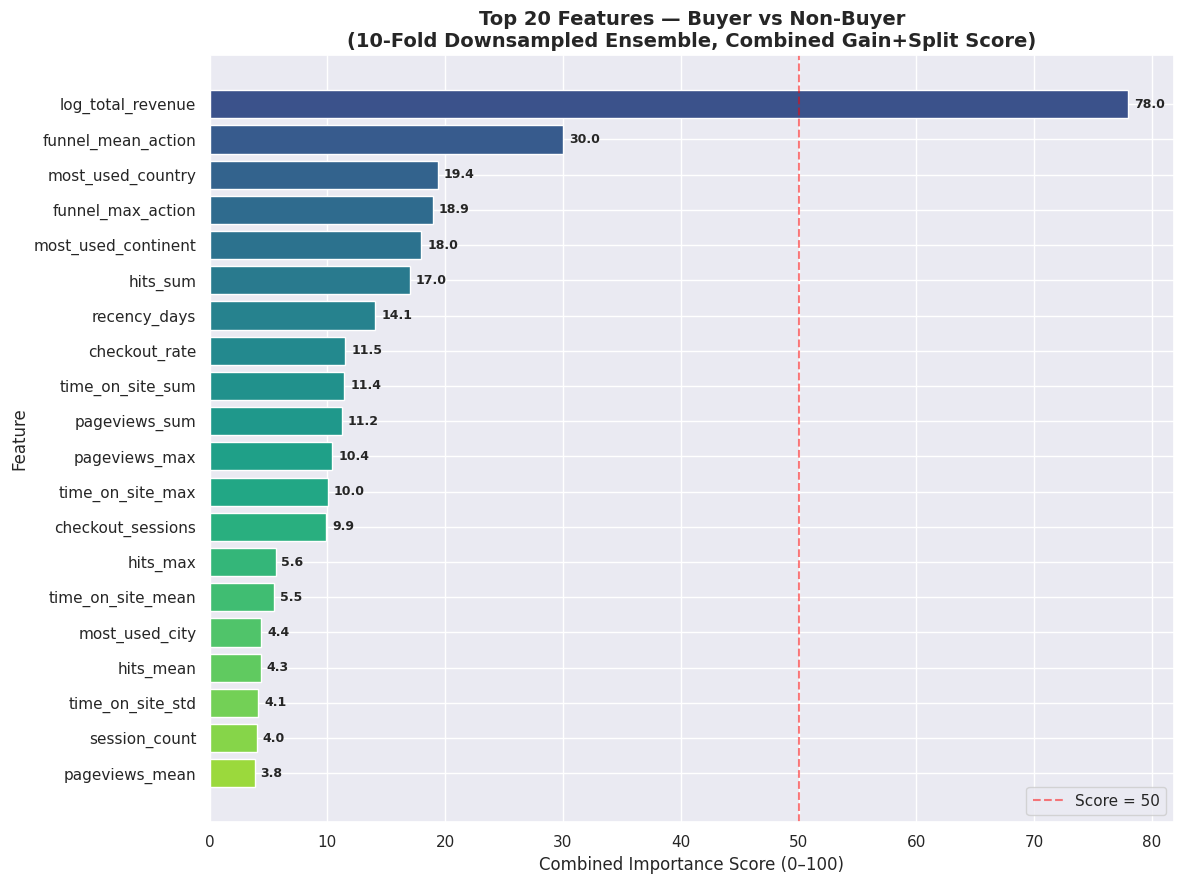

In [8]:
# ── Plot 1: Top 20 features by Combined Score ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

top20 = feature_scores.head(20).copy()
colors = plt.cm.viridis(np.linspace(0.85, 0.25, len(top20)))

bars = ax.barh(top20['Feature'][::-1], top20['Combined_Score'][::-1], color=colors)

for bar, val in zip(bars, top20['Combined_Score'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

ax.set_title(
    f'Top 20 Features — Buyer vs Non-Buyer\n'
    f'({NUM_CHUNKS}-Fold Downsampled Ensemble, Combined Gain+Split Score)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Combined Importance Score (0–100)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='Score = 50')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'feature_importance_scores.png', dpi=150, bbox_inches='tight')
plt.show()

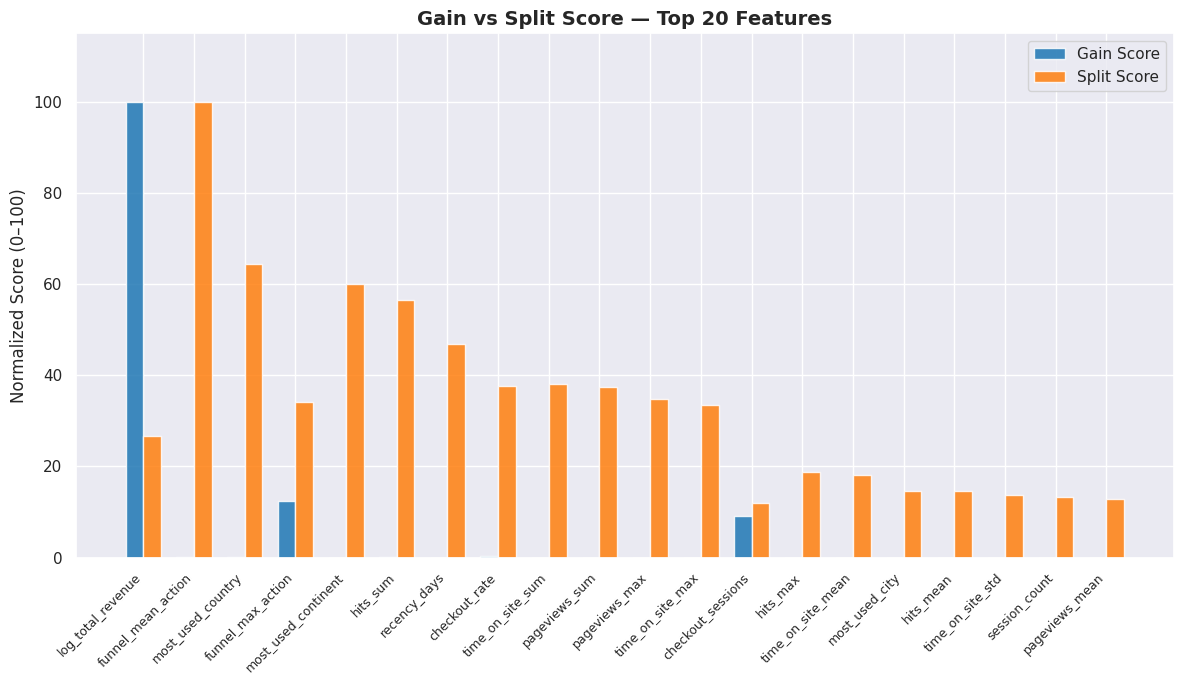


💡 Interpretation:
   Gain Score  = how much this feature improves classification quality
   Split Score = how often this feature is used in decision splits
   High Gain + Low Split = powerful but selective feature
   High Split + Low Gain = noisy feature used often but with little benefit


In [9]:
# ── Plot 2: Gain vs Split comparison for top 20 ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

top20 = feature_scores.head(20)
x     = np.arange(len(top20))
width = 0.35

bars1 = ax.bar(x - width/2, top20['Normalized_Gain'],  width, label='Gain Score',  color='#1f77b4', alpha=0.85)
bars2 = ax.bar(x + width/2, top20['Normalized_Split'], width, label='Split Score', color='#ff7f0e', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top20['Feature'], rotation=45, ha='right', fontsize=9)
ax.set_title('Gain vs Split Score — Top 20 Features', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Score (0–100)')
ax.legend()
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'feature_gain_vs_split.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Interpretation:')
print('   Gain Score  = how much this feature improves classification quality')
print('   Split Score = how often this feature is used in decision splits')
print('   High Gain + Low Split = powerful but selective feature')
print('   High Split + Low Gain = noisy feature used often but with little benefit')

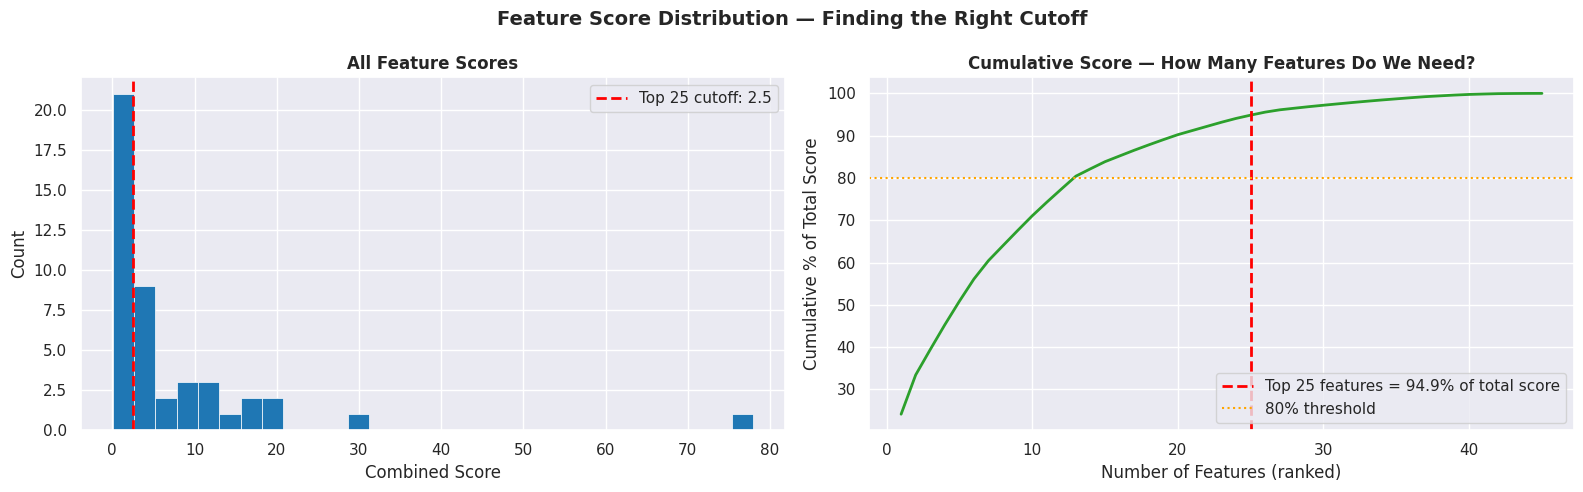


💡 Top 25 features capture 94.9% of total importance score
   Remaining 20 features contribute only 5.1%


In [10]:
# ── Plot 3: Score distribution — where is the cutoff? ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Feature Score Distribution — Finding the Right Cutoff', 
             fontsize=14, fontweight='bold')

# Distribution of all combined scores
axes[0].hist(feature_scores['Combined_Score'], bins=30, color='#1f77b4', 
             edgecolor='white', linewidth=0.5)
axes[0].axvline(feature_scores.iloc[TOP_N-1]['Combined_Score'], 
                color='red', linestyle='--', linewidth=2,
                label=f'Top {TOP_N} cutoff: {feature_scores.iloc[TOP_N-1]["Combined_Score"]:.1f}')
axes[0].set_title('All Feature Scores', fontweight='bold')
axes[0].set_xlabel('Combined Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Cumulative score contribution
cumsum = feature_scores['Combined_Score'].cumsum()
total_score = feature_scores['Combined_Score'].sum()
axes[1].plot(range(1, len(cumsum)+1), cumsum / total_score * 100, 
             color='#2ca02c', linewidth=2)
axes[1].axvline(TOP_N, color='red', linestyle='--', linewidth=2,
                label=f'Top {TOP_N} features = {cumsum.iloc[TOP_N-1]/total_score*100:.1f}% of total score')
axes[1].axhline(80, color='orange', linestyle=':', label='80% threshold')
axes[1].set_title('Cumulative Score — How Many Features Do We Need?', fontweight='bold')
axes[1].set_xlabel('Number of Features (ranked)')
axes[1].set_ylabel('Cumulative % of Total Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'feature_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

pct_covered = cumsum.iloc[TOP_N-1] / total_score * 100
print(f'\n💡 Top {TOP_N} features capture {pct_covered:.1f}% of total importance score')
print(f'   Remaining {len(feature_scores)-TOP_N} features contribute only {100-pct_covered:.1f}%')

---
## 🔍 Section 8 — AUC Stability Check

Check that all 10 iterations had consistent quality.  
If one iteration had much lower AUC, it means that chunk of non-buyers was unusual.

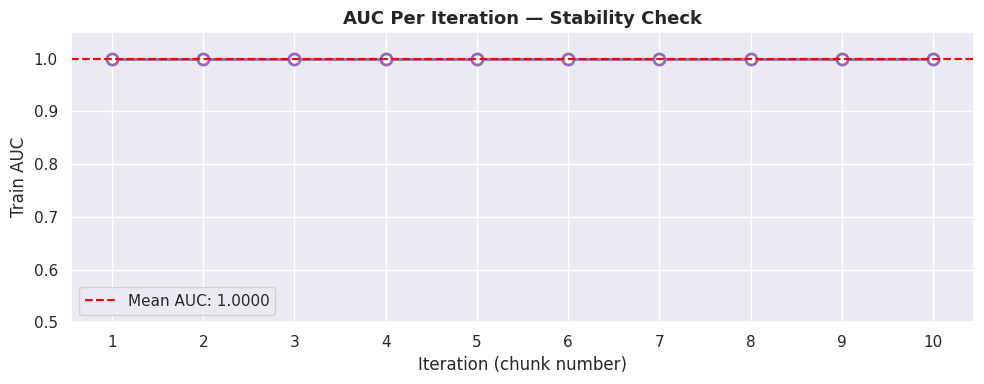

AUC per iteration:
  Chunk  1: 1.0000  ████████████████████████████████████████
  Chunk  2: 1.0000  ████████████████████████████████████████
  Chunk  3: 1.0000  ████████████████████████████████████████
  Chunk  4: 1.0000  ████████████████████████████████████████
  Chunk  5: 1.0000  ████████████████████████████████████████
  Chunk  6: 1.0000  ████████████████████████████████████████
  Chunk  7: 1.0000  ████████████████████████████████████████
  Chunk  8: 1.0000  ███████████████████████████████████████
  Chunk  9: 1.0000  ████████████████████████████████████████
  Chunk 10: 1.0000  ████████████████████████████████████████

Mean : 1.0000
Std  : 0.0000
✅ AUC is very stable — feature scores are reliable


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(range(1, NUM_CHUNKS+1), auc_scores, marker='o', linewidth=2,
        color='#9467bd', markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(range(1, NUM_CHUNKS+1), 
                [np.mean(auc_scores) - np.std(auc_scores)] * NUM_CHUNKS,
                [np.mean(auc_scores) + np.std(auc_scores)] * NUM_CHUNKS,
                alpha=0.2, color='#9467bd')
ax.axhline(np.mean(auc_scores), color='red', linestyle='--', 
           label=f'Mean AUC: {np.mean(auc_scores):.4f}')
ax.set_title('AUC Per Iteration — Stability Check', fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration (chunk number)')
ax.set_ylabel('Train AUC')
ax.set_xticks(range(1, NUM_CHUNKS+1))
ax.set_ylim(0.5, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'auc_stability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC per iteration:')
for i, auc in enumerate(auc_scores, 1):
    bar = '█' * int(auc * 40)
    print(f'  Chunk {i:>2}: {auc:.4f}  {bar}')
print(f'\nMean : {np.mean(auc_scores):.4f}')
print(f'Std  : {np.std(auc_scores):.4f}')
if np.std(auc_scores) < 0.02:
    print('✅ AUC is very stable — feature scores are reliable')
elif np.std(auc_scores) < 0.05:
    print('⚠️  Some variation — scores are mostly reliable')
else:
    print('⚠️  High variation — consider increasing NUM_CHUNKS for more stability')

---
## 💾 Section 9 — Save Feature Scores & Build Important Feature Datasets

In [12]:
# ── Save full feature importance table ───────────────────────────────────────
scores_path = OUTPUT_PATH + 'feature_importance_scores.csv'
feature_scores.to_csv(scores_path, index=True)
print(f'✅ Feature scores saved: {scores_path}')
print(f'   Total features ranked: {len(feature_scores)}')

✅ Feature scores saved: /kaggle/working/feature_importance_scores.csv
   Total features ranked: 45


In [13]:
# ── Select top N features ─────────────────────────────────────────────────────
top_features = feature_scores.head(TOP_N)['Feature'].tolist()

print(f'🎯 Selected top {TOP_N} features:')
for i, feat in enumerate(top_features, 1):
    score = feature_scores[feature_scores['Feature'] == feat]['Combined_Score'].values[0]
    print(f'  {i:>3}. {feat:<45} score: {score:.1f}')

🎯 Selected top 25 features:
    1. log_total_revenue                             score: 78.0
    2. funnel_mean_action                            score: 30.0
    3. most_used_country                             score: 19.4
    4. funnel_max_action                             score: 18.9
    5. most_used_continent                           score: 18.0
    6. hits_sum                                      score: 17.0
    7. recency_days                                  score: 14.1
    8. checkout_rate                                 score: 11.5
    9. time_on_site_sum                              score: 11.4
   10. pageviews_sum                                 score: 11.2
   11. pageviews_max                                 score: 10.4
   12. time_on_site_max                              score: 10.0
   13. checkout_sessions                             score: 9.9
   14. hits_max                                      score: 5.6
   15. time_on_site_mean                             score: 5.5


In [14]:
# ── Build important-features train dataset ────────────────────────────────────
# Keep: fullVisitorId + top features + target
keep_train_cols = ['fullVisitorId'] + [f for f in top_features if f in train.columns]
if 'target' in train.columns:
    keep_train_cols.append('target')

train_important = train[keep_train_cols].copy()

# ── Build important-features test dataset ────────────────────────────────────
keep_test_cols = ['fullVisitorId'] + [f for f in top_features if f in test.columns]

test_important = test[keep_test_cols].copy()

# ── Check for any missing features between train and test ────────────────────
train_feats = set([c for c in train_important.columns if c not in ['fullVisitorId', 'target']])
test_feats  = set([c for c in test_important.columns  if c not in ['fullVisitorId']])
missing_in_test  = train_feats - test_feats
missing_in_train = test_feats  - train_feats

if missing_in_test:
    print(f'⚠️  Features in train but not test: {missing_in_test}')
    print('   → Filling with 0 in test')
    for col in missing_in_test:
        test_important[col] = 0

if missing_in_train:
    print(f'⚠️  Features in test but not train: {missing_in_train}')

print(f'\n✅ Important-features train: {train_important.shape}')
print(f'✅ Important-features test : {test_important.shape}')


✅ Important-features train: (1323730, 27)
✅ Important-features test : (296530, 26)


In [15]:
# ── Save both datasets ────────────────────────────────────────────────────────
train_imp_path = OUTPUT_PATH + 'users_train_important.csv'
test_imp_path  = OUTPUT_PATH + 'users_test_important.csv'

train_important.to_csv(train_imp_path, index=False)
test_important.to_csv(test_imp_path,  index=False)

print('💾 Saved important-features datasets:')
print(f'   ✅ users_train_important.csv  →  {os.path.getsize(train_imp_path)/1e6:.1f} MB  shape: {train_important.shape}')
print(f'   ✅ users_test_important.csv   →  {os.path.getsize(test_imp_path)/1e6:.1f} MB  shape: {test_important.shape}')
print(f'\n   Features reduced: {X.shape[1]} → {len(top_features)} ({len(top_features)/X.shape[1]*100:.1f}% of original)')

gc.collect()

💾 Saved important-features datasets:
   ✅ users_train_important.csv  →  152.8 MB  shape: (1323730, 27)
   ✅ users_test_important.csv   →  33.6 MB  shape: (296530, 26)

   Features reduced: 45 → 25 (55.6% of original)


15

---
## 📋 Section 10 — Phase 3.5 Summary

| Step | Action | Status |
|---|---|---|
| Load user-level data | `users_train.csv` from Phase 3 | ✅ |
| Separate buyers / non-buyers | 1 vs 0 binary target | ✅ |
| Split non-buyers into 10 chunks | Randomized, equal-sized | ✅ |
| Train LightGBM × 10 iterations | All buyers + one chunk each time | ✅ |
| Record gain + split importance | Both metrics per iteration | ✅ |
| Average scores | Combined score = 70% gain + 30% split | ✅ |
| AUC stability check | Verified iteration quality | ✅ |
| Rank all features | Sorted by combined score | ✅ |
| Build output datasets | Top 25 features only | ✅ |
| Save 4 output files | Scores CSV + 2 feature plots + 2 datasets | ✅ |

---

### 📤 Output Files

| File | Description |
|---|---|
| `feature_importance_scores.csv` | All features ranked by combined score |
| `feature_importance_scores.png` | Top 20 features bar chart |
| `feature_gain_vs_split.png` | Gain vs split comparison |
| `feature_score_distribution.png` | Score distribution + cumulative curve |
| `auc_stability.png` | AUC per iteration stability check |
| `users_train_important.csv` | 🎯 Train dataset — top features only |
| `users_test_important.csv` | 🎯 Test dataset — top features only |

---

### ➡️ Next: Phase 4 — Modeling

Use `users_train_important.csv` and `users_test_important.csv` as your **second dataset**  
alongside the full feature datasets from Phase 3.  
Compare model performance: does the focused dataset beat the full one?